Santiago Andrés Acosta Díaz

# Tarea de regresión 

En esta tarea, se pide resolver una ecuación (root-searching) en donde, a priori, deberíamos haber podido realizar la regresión de una función dados un set de puntos.

## Regresión inicial

Lo que se busca es resolver para $\lambda$ y $A$ en 

$$
\gamma(t) = A e^{\lambda t}
$$

dados unos sets de datos $\{ t_i \}_i^n$ y $\{ \gamma_i \}_i^n$.

Podemos transformar la ecuación inicial a partir del logaritmo natural a

$$
\ln(\gamma) = \ln(A) + \lambda t = a_0 + a_1 t,
$$

donde $a_0 = ln(A)$ y $a_1 = \lambda$ pueden ser encontrados a partir de la regresión lineal entre las variables $z = \ln(\gamma)$ y $t$ como

$$
a_1 = \lambda = \frac{n \sum_i^n t_i z_i - \sum_i^n t_i \sum_i^n \gamma_i}{n \sum_i^n t_i^2 - \left( \sum_i^n t_i\right)^2}
$$

y 

$$
a_0 = \ln(A) = \bar z - a_1 \bar t
$$

Estimación de $\lambda = -0.1150496260264895$
Estimación de $A = 0.9997385360041294$


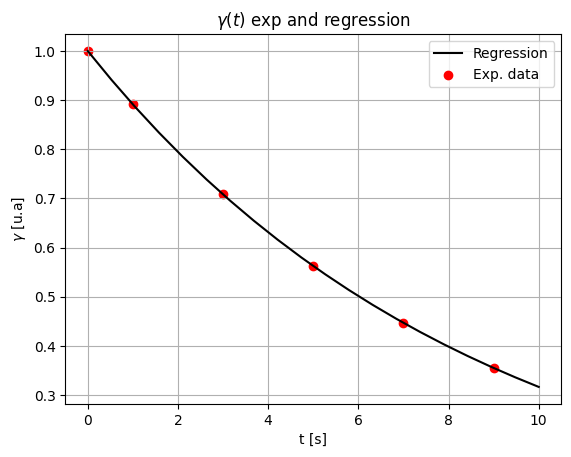

In [1]:
# Importamos librerías 
import numpy as np
from numpy import exp, log
import matplotlib.pyplot as plt


# Escribimos los datos que se nos dieron
ts = np.array([0.0, 1.0, 3.0, 5.0, 7.0, 9.0])
gammas = np.array([1.0, 0.891, 0.708, 0.562, 0.447, 0.355])
zs = log(gammas)
n = ts.size

# Escribimos la función como tal
def real_function(t, A, lamb):
    return A * exp(lamb * t)


# Hacemos el cálculo para hallar a_1 y a_0
a1 = (n * np.sum( ts * zs ) - np.sum( ts )*np.sum(zs)) / (n*np.sum( np.power(ts, 2) ) - np.power(np.sum(ts), 2))
a0 = np.mean(zs) - a1*np.mean(ts)

# Recuperamos los parámetros originales
lamb_est = a1
A_est = exp(a0)

print(rf"Estimación de $\lambda = {lamb_est}$")
print(rf"Estimación de $A = {A_est}$")

ts_graph = np.linspace(0.0, 10.0, 20)
gammas_graph = real_function(ts_graph, A_est, lamb_est)


plt.plot(ts_graph, gammas_graph, c="black", label = "Regression")
plt.scatter(ts, gammas, c="r", label = "Exp. data")
plt.title(r"$\gamma (t)$ exp and regression")
plt.xlabel("t [s]")
plt.ylabel(r"$\gamma$ [u.a]")
plt.legend()
plt.grid()
plt.show()

Vemos que este método, para esta función, da buenos resultados al ser linealizable. 

## Regresión sin linealizar

Ahora, si buscamos no linealizar, lo que hacemos analíticament es minimizar la diferencia de cuadrados entre los datos experimentales y las estimaciones de un modelo dados ciertos parámetros. Esto es lo que generalmente conocemos como "mínimos cuadrados", pero para lo que haremos, la diferencia radica en que podemos hallar una expresión analítica de estos mínimos cuadrados a partir de derivar la función de error y hallar su punto estable (esperando que este sea un mínimo).

En el caso de $\lambda$, esta función viene dada por (dada en las diapositivas)

$$
    f(\lambda) = \sum_i^n \gamma_i t_i e^{\lambda t_i} - \frac{ \sum_i^n \gamma_i e^{\lambda t_i}  }{ \sum_i^n e^{2 \lambda t_i}  } \sum_i^n t_i e^{2 \lambda t_i} = 0
$$

lo cual se reduce a un problema de búsqueda de raíces, que resolveremos por bisección.

Ahora, para hallar $A$ de esta forma, podemos considerar que ya conoceríamos $\lambda$, y a partir de la ecuación (8) __(aunque podemos llegar a exactamente el mismo resultado de la ecuación (9)__ llegar a que

$$
    A =  \frac{ \sum_i^n\gamma_i e^{\lambda t_i} }{ \sum_i^ne^{2\lambda t_i} }
$$

Estimación de lambda por bisección = -0.11508303839359499
Estimación de A por bisección = 0.9998413983035409


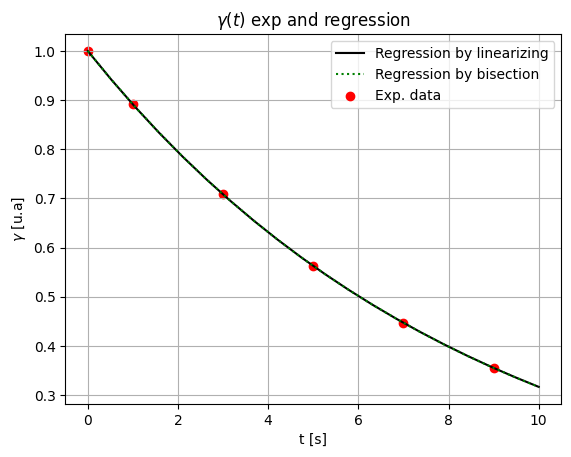

In [2]:
def lambda_function(lamb):
    # La función de minimización de lambda
    first_term = np.sum( gammas * ts * exp(lamb * ts) )

    second_term_up = np.sum( gammas * exp(lamb * ts) )
    second_term_down = np.sum( exp(2 * lamb * ts) )
    second_term_right = np.sum( ts * exp(2 * lamb * ts) )

    return first_term - (second_term_up / second_term_down) * second_term_right
    

def bisection_step(left, right, func):
    # Un único paso de bisección
    mid = np.mean([left, right])
    
    left_eval = func(left)
    mid_eval = func(mid)
    right_eval = func(right)

    flag = left_eval * right_eval < 0 

    if left_eval * mid_eval < 0 :
        return left, mid
    elif mid_eval * right_eval < 0:
        return mid, right
    else:
        print("Something bad happened")



def apply_bisection(l0, r0, func = lambda_function, tol = 1e-8):
    # Aplica bisección a una tolerancia dada

    left = l0 
    right = r0

    while abs(left - right) > tol:
        left, right = bisection_step(left, right, func)

    return (left + right) / 2.0


# Aplicamos condiciones iniciales
lamb0_left = lamb_est - 0.089
lamb0_right = lamb_est + 0.089


# Hallamos lambda por bisección
lambda_est_bisection = apply_bisection(lamb0_left, lamb0_right, lambda_function)

# Estimamos A como se mostró anteriormente
A_est_bisection = np.sum( gammas * exp(lambda_est_bisection * ts) ) / np.sum( exp(2 * lambda_est_bisection * ts) )

print(f"Estimación de lambda por bisección = {lambda_est_bisection}")
print(f"Estimación de A por bisección = {A_est_bisection}")


# Hacemos el plot
plt.plot(ts_graph, gammas_graph, c="black", label = "Regression by linearizing")
plt.plot(ts_graph, real_function(ts_graph, A_est_bisection, lambda_est_bisection), c="green", label = "Regression by bisection", linestyle = 'dotted')
plt.scatter(ts, gammas, c="r", label = "Exp. data")
plt.title(r"$\gamma (t)$ exp and regression")
plt.xlabel("t [s]")
plt.ylabel(r"$\gamma$ [u.a]")
plt.legend()
plt.grid()
plt.show()